</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>La aproximación de Apophis en 2029</center></b><h3>
</p>

<hr/>
<b>Nombre</b>: María Fernanda Montenegro Pabon
<br/>
<b>Cédula</b>: 1193406014
<hr/>

## Enunciado
En abril de 2029 el asteroide **(99942) Apophis** tendrá una aproximación extrema con la Tierra. Por el tamaño del asteroide, esta aproximación es considerada uno de los eventos astronómicos más importantes de esta década. En este proyecto usaremos la teoría, los métodos y los algorítmos vistos en el curso de Mecánica Celeste para estudiar la aproximación del asteroide.

El objetivo de este trabajo es que experimentes de primera mano lo que las personas expertas en mecánica celeste hacen cuando estudian las amenazas de asteroides. Aprovecha cada cosa que veas en el curso para crear un reporte científico que explore a fondo las características dinámicas de esta aproximación.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Integración de la trayectoria del asteroide usando un integrador de N cuerpos y teniendo en cuenta los efectos de todos los planetas.
- Cálculo de la fecha y hora exacta de aproximación a la Tierra.
- Determinación de la distancia mínima de la órbita del asteroide a la órbita de la Tierra.
- Cálculo usando solo la teoría del problema de los dos cuerpos de la aproximación y comparación con la teoría de N cuerpos.
- Cálculo del cambio de la órbita heliocéntrica del asteroide después de su paso cerca de la Tierra.
- Aplicación de la teoría del problema de N cuerpos al asteroide.

En todos los casos debe ser evidente cómo estás usando los resultados teóricos que vemos en el curso.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Solución

### Introducción

El asteroide **(99942) Apophis** tendrá una aproximación extrema con la Tierra en abril de 2029, pasando a menos de 40,000 km de la superficie.
En este proyecto se estudia la dinámica de este encuentro usando los métodos vistos en el curso de Mecánica Celeste:

1. Integración numérica con el método **leapfrog** y comparación con `ncuerpos_solucion`.
2. Simulación de N cuerpos con condiciones reales usando **REBOUND** y efemérides de NASA Horizons.
3. Análisis del encuentro con la teoría del **problema de dos cuerpos**: trayectoria hiperbólica, distancia mínima y comparación con el resultado de N cuerpos.
4. Cambio en los **elementos orbitales** de Apophis antes y después del paso cerca a la tierra.

### Librerías y sistema de unidades

Se utilizan unidades canónicas de mecánica celeste: distancias en **UA**, masas en **masas solares**  y tiempo en **años**. Con estas unidades la constante gravitacional se normaliza a:

$$G = 1 \quad \text{UA}^3 \cdot M_\odot^{-1} \cdot \text{año}^{-2}$$

Esto simplifica las ecuaciones del movimiento.

In [4]:
!pip install -Uq numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install -Uq matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install -Uq pymcel


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install -Uq rebound


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import copy
import rebound 

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [9]:
UL = 1 * pc.constantes.au
UM = pc.constantes.mu_sun / pc.constantes.G
UT = 1 * pc.constantes.año

UV = (UL / UT)
UE = ((UM * UL ** 2) / UT ** 2)
UH = ((UM * UL ** 2) / UT)

G_ = pc.constantes.G * UM * UT ** 2 / UL ** 3

### Integración con el método Leapfrog

El método **leapfrog** es un integrador visto en clase el cual conserva bien la energía a largo plazo. Actualiza posiciones y velocidades en cada paso de tiempo $\Delta t$.

La aceleración gravitacional sobre cada cuerpo se calcula como:

$$\vec{a}_i = \sum_{j \neq i} \frac{G \, m_j (\vec{r}_j - \vec{r}_i)}{|\vec{r}_j - \vec{r}_i|^3}$$

#### Sistema inicial: Sol, Tierra y Apophis

Se comienza con un sistema simplificado de tres cuerpos para una mejor visualización de sus órbitas y verificar que el integrador funciona correctamente antes de agregar más cuerpos.

In [10]:
sistema_apophis = [
    dict(m=1.0,
         r=np.array([0.0, 0.0, 0.0]),
         v=np.array([0.0, 0.0, 0.0])),  # Sol

    dict(m=3e-6,
         r=np.array([1.0, 0.0, 0.0]),
         v=np.array([0.0, 1.0, 0.0])),  # Tierra 

    dict(m=3.07e-20,
         r=np.array([0.746, 0.0, 0.0]),
         v=np.array([0.0, 1.27, 0.0]))  # Apophis 
]

In [11]:
def aceleraciones(sistema_apophis):
    n = len(sistema_apophis)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        if i == 0:  # Sol fijo
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema_apophis[j]['r'] - sistema_apophis[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema_apophis[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

In [12]:
def paso_leapfrog(sistema_apophis, dt):
    a = aceleraciones(sistema_apophis)
    for i in range(1, len(sistema_apophis)): 
        sistema_apophis[i]['v'] += 0.5 * a[i] * dt

    for i in range(1, len(sistema_apophis)):  
        sistema_apophis[i]['r'] += sistema_apophis[i]['v'] * dt

    a_new = aceleraciones(sistema_apophis)
    for i in range(1, len(sistema_apophis)):  
        sistema_apophis[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.001
pasos = 20000

trayectorias = [[] for _ in sistema_apophis]

for _ in range(pasos):
    paso_leapfrog(sistema_apophis, dt)
    for i in range(len(sistema_apophis)):
        trayectorias[i].append(sistema_apophis[i]['r'].copy())


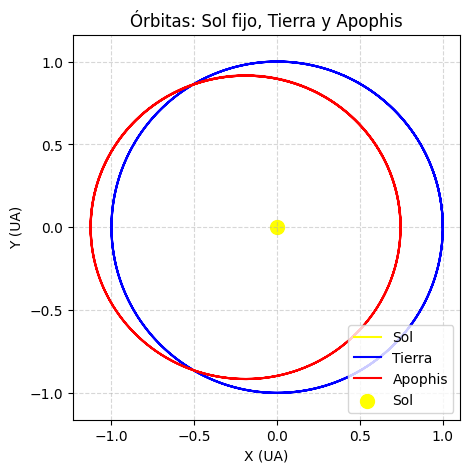

In [13]:
colors = ['yellow', 'blue', 'red']
labels = ['Sol', 'Tierra', 'Apophis']

plt.figure(figsize=(5,5))
for i in range(len(sistema_apophis)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])
   
plt.scatter(0, 0, color='yellow', s=100, label='Sol')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra y Apophis')
plt.show()


#### Comparación con `ncuerpos_solucion`

Se resuelve el mismo sistema usando `ncuerpos_solucion` de `pymcel`, que utiliza un integrador adaptativo de orden superior. Esto permite comparar visualmente las trayectorias obtenidas con el leapfrog y verificar que ambos métodos producen resultados consistentes.

In [14]:
sistema_leap = sistema_apophis
sistema_ref  = copy.deepcopy(sistema_apophis)

ts = np.linspace(0, 10, 1000)

rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_ref, ts)

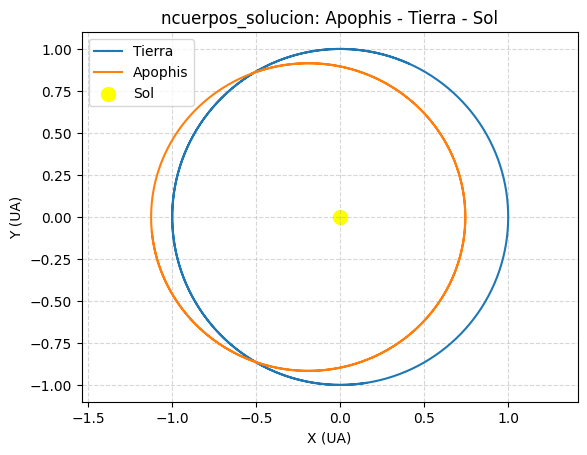

In [15]:
for i in range(len(sistema_ref)):
    tray = rs[i]
    
    if labels[i] != 'Sol':
        plt.plot(tray[:,0], tray[:,1], label=labels[i])
    else:
        plt.plot(tray[:,0], tray[:,1], color='blue') 
        
plt.scatter(0, 0, color='yellow', s=100, label='Sol')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title("ncuerpos_solucion: Apophis - Tierra - Sol")
plt.axis('equal')
plt.show()

#### Adición de planetas internos

Se agregan Venus y Mercurio al sistema para observar la interacción gravitacional con más cuerpos.

In [16]:
sistema_internos = [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=3.07e-20, r=np.array([0.746, 0.0, 0.0]), v=np.array([0.0, 1.27, 0.0])), # Apophis
    dict(m=2.4e-6,r=np.array([0.72, 0.0, 0.0]),v=np.array([0.0, 1.18, 0.0])), #Venus
    dict(m=1.7e-7,r=np.array([0.39, 0.0, 0.0]),v=np.array([0.0, 1.6, 0.0])) #Mercurio
]

In [17]:
def aceleraciones(sistema_internos):
    n = len(sistema_internos)
    a = [np.zeros(3) for _ in range(n)]
    
    for i in range(n):
        if i == 0:  # Sol fijo
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema_internos[j]['r'] - sistema_internos[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema_internos[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

In [18]:
def paso_leapfrog(sistema_internos, dt):
    a = aceleraciones(sistema_internos)
    for i in range(1, len(sistema_internos)): 
        sistema_internos[i]['v'] += 0.5 * a[i] * dt

    for i in range(1, len(sistema_internos)): 
        sistema_internos[i]['r'] += sistema_internos[i]['v'] * dt

    a_new = aceleraciones(sistema_internos)
    for i in range(1, len(sistema_internos)):  
        sistema_internos[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.0002
pasos = 70000

trayectorias = [[] for _ in sistema_internos]

for _ in range(pasos):
    paso_leapfrog(sistema_internos, dt)
    for i in range(len(sistema_internos)):
        trayectorias[i].append(sistema_internos[i]['r'].copy())

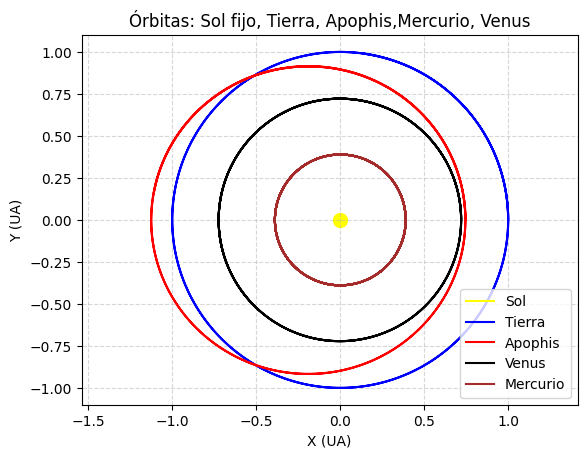

In [19]:
colors = ['yellow', 'blue', 'red', 'black','brown']
labels = ['Sol', 'Tierra', 'Apophis', 'Venus', 'Mercurio']

for i in range(len(sistema_internos)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i])
   

plt.scatter(0, 0, color='yellow', s=100)  
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra, Apophis,Mercurio, Venus')
plt.show()


Se compara nuevamente con `ncuerpos_solucion` para verificar la consistencia del integrador con el sistema ampliado.

In [20]:
sistema_leap = sistema_internos
sistema_ref  = copy.deepcopy(sistema_internos)

ts = np.linspace(0, 10, 1000)

rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_ref, ts)

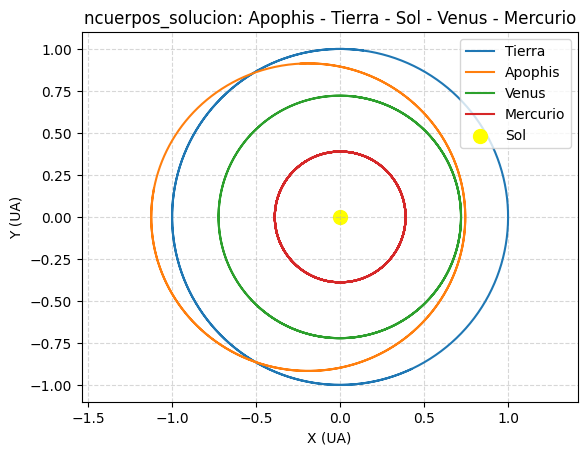

In [21]:
for i in range(len(sistema_ref)):
    tray = rs[i]
    
    if labels[i] != 'Sol':
        plt.plot(tray[:,0], tray[:,1], label=labels[i])
    else:
        plt.plot(tray[:,0], tray[:,1], color='blue') 
        
plt.scatter(0, 0, color='yellow', s=100, label='Sol')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title("ncuerpos_solucion: Apophis - Tierra - Sol - Venus - Mercurio")
plt.axis('equal')
plt.show()

#### Inclusión de Júpiter 

Se añade Júpiter al sistema, el principal perturbador gravitacional del sistema solar debido a su masa. 

#### Sistema completo con todos los planetas

Se incluyen todos los planetas del sistema solar: Mercurio, Venus, Tierra, Marte, Júpiter, Saturno, Urano y Neptuno junto con Apophis. Se resuelve tanto con el **leapfrog propio** como con `ncuerpos_solucion` para comparar ambos métodos en un sistema de mayor complejidad.

In [22]:
sistema_completos= [
    dict(m=1.0, r=np.array([0.0, 0.0, 0.0]), v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6, r=np.array([1.0, 0.0, 0.0]), v=np.array([0.0, 1.0, 0.0])), # Tierra
    dict(m=3.07e-20, r=np.array([0.746, 0.0, 0.0]), v=np.array([0.0, 1.27, 0.0])), # Apophis
    dict(m=3.2e-7, r=np.array([1.52, 0.0, 0.0]), v=np.array([0.0, 0.81, 0.0])), # Marte
    dict(m=2.4e-6, r=np.array([0.72, 0.0, 0.0]), v=np.array([0.0, 1.18, 0.0])), # Venus
    dict(m=1.7e-7, r=np.array([0.39, 0.0, 0.0]), v=np.array([0.0, 1.6, 0.0])), # Mercurio
    dict(m=9.5e-4, r=np.array([5.2, 0.0, 0.0]), v=np.array([0.0, 0.43, 0.0])),  # Júpiter
    dict(m=2.86e-4, r=np.array([9.58, 0.0, 0.0]), v=np.array([0.0, 0.322, 0.0])),  # Saturno
    dict(m=4.37e-5, r=np.array([19.2, 0.0, 0.0]), v=np.array([0.0, 0.228, 0.0])),  # Urano
    dict(m=5.15e-5, r=np.array([30.05, 0.0, 0.0]), v=np.array([0.0, 0.182, 0.0]))  # Neptuno
]

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


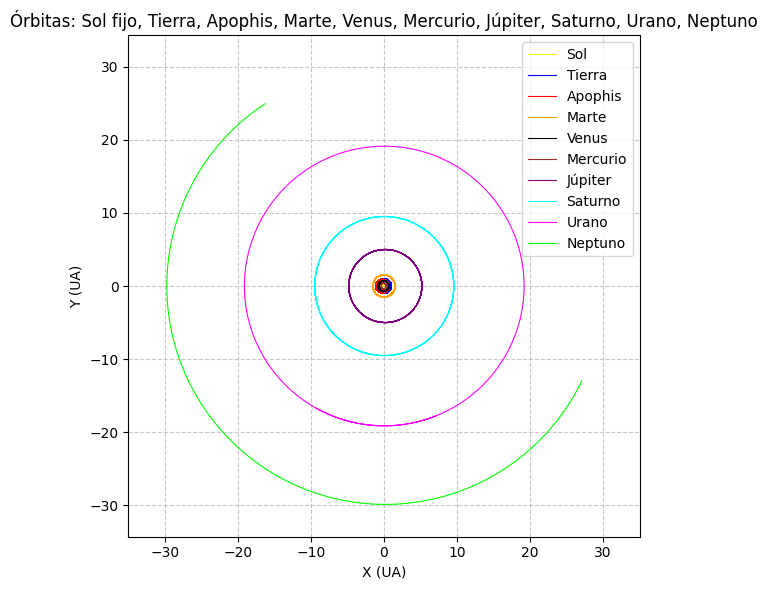

In [24]:
def aceleraciones(sistema_completos):
    n = len(sistema_completos)
    a = [np.zeros(3) for _ in range(n)]
    for i in range(n):
        if i == 0:  # Sol fijo
            continue
        for j in range(n):
            if i != j:
                r_vec = sistema_completos[j]['r'] - sistema_completos[i]['r']
                eps = 1e-5
                dist = np.linalg.norm(r_vec) + 1e-10
                a[i] += sistema_completos[j]['m'] * r_vec / (dist**2 + eps**2)**(3/2)
    return a

def paso_leapfrog(sistema_completos, dt):
    a = aceleraciones(sistema_completos)
    for i in range(1, len(sistema_completos)):
        sistema_completos[i]['v'] += 0.5 * a[i] * dt
    for i in range(1, len(sistema_completos)):
        sistema_completos[i]['r'] += sistema_completos[i]['v'] * dt
    a_new = aceleraciones(sistema_completos)
    for i in range(1, len(sistema_completos)):
        sistema_completos[i]['v'] += 0.5 * a_new[i] * dt

# Parámetros de simulación
dt = 0.0005
pasos = 1200000  

trayectorias = [[] for _ in sistema_completos]

for step in range(pasos):
    paso_leapfrog(sistema_completos, dt)
    if step % 10 == 0:
        for i in range(len(sistema_completos)):
            trayectorias[i].append(sistema_completos[i]['r'].copy())

colors = ['yellow', 'blue', 'red', 'orange', 'black', 'brown', 'purple', 'cyan', 'magenta', 'lime']
labels = ['Sol', 'Tierra', 'Apophis', 'Marte', 'Venus', 'Mercurio', 'Júpiter','Saturno','Urano','Neptuno']

# Gráfica
plt.figure(figsize=(6,6))
for i in range(len(sistema_completos)):
    tray = np.array(trayectorias[i])
    plt.plot(tray[:,0], tray[:,1], color=colors[i], label=labels[i], linewidth=0.8)

plt.scatter(0, 0, color='yellow', s=100)  # Sol en el origen
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axis('equal')
plt.xlabel('X (UA)')
plt.ylabel('Y (UA)')
plt.title('Órbitas: Sol fijo, Tierra, Apophis, Marte, Venus, Mercurio, Júpiter, Saturno, Urano, Neptuno')
plt.xlim(-35, 35)
plt.ylim(-35, 35)
plt.tight_layout()
plt.show()

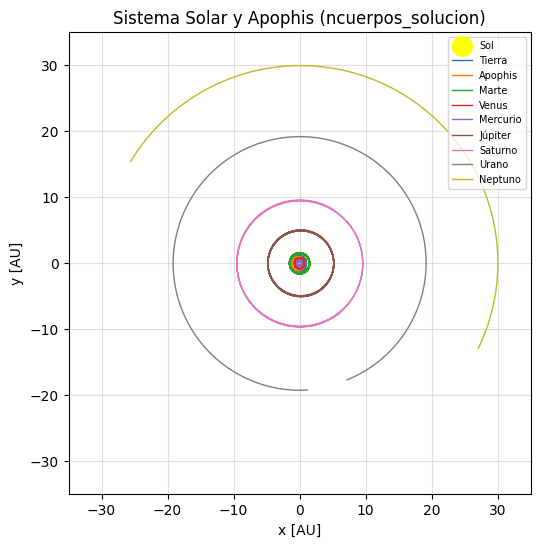

In [25]:
# Tiempo suficiente para incluir a Neptuno
ts = np.linspace(0, 500, 10000)

# Resolver sistema
rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_completos, ts)

labels = ['Sol', 'Tierra', 'Apophis', 'Marte', 'Venus', 'Mercurio', 
          'Júpiter', 'Saturno', 'Urano', 'Neptuno']


for i in range(len(rs)):
    rs[i][:,0] -= rs[0][:,0]
    rs[i][:,1] -= rs[0][:,1]

plt.figure(figsize=(6,6))

for i in range(len(sistema_completos)):
    tray = rs[i]
    
    if i == 0:
        plt.scatter(0, 0, color='yellow', s=200, label='Sol')
    else:
        plt.plot(tray[:,0], tray[:,1], linewidth=1, label=labels[i])

plt.xlim(-35, 35)
plt.ylim(-35, 35)
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right', fontsize=7)
plt.title("Sistema Solar y Apophis (ncuerpos_solucion)")
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.show()

#### Análisis visual de las órbitas

Al comparar las trayectorias obtenidas con la visualización del [JPL Small-Body Database](https://ssd.jpl.nasa.gov/tools/sbdb_lookup.html#/?sstr=apophis&view=VOP) se observa:

- La órbita de Apophis se ubica entre las órbitas de Venus y Marte, cruzando la órbita de la Tierra, lo cual es consistente con lo que muestra JPL.
- Las distancias orbitales de todos los planetas coinciden con los valores reales: Júpiter ~5 UA, Saturno ~10 UA, Urano ~19 UA y Neptuno ~30 UA.
- Las órbitas de los planetas exteriores (Saturno, Urano y Neptuno) aparecen incompletas ya que sus periodos orbitales son muy largos: Saturno tarda ~29 años, Urano ~84 años y Neptuno ~165 años en completar una órbita. El tiempo de integración no es suficiente para completar sus trayectorias.

#### Energía del sistema y teorema del virial

Se incluye la Luna en el sistema y se calculan la energía cinética $K$, la energía potencial $U$ y la energía total $E = K + U$ del sistema. Además se evalúa el cociente $K/|U|$, que según el teorema del virial debe ser aproximadamente $0.5$ para un sistema ligado.

In [26]:
m_luna = 3.694e-8
dist_luna = 0.00257
vel_luna = 0.034

sistema_completos_luna = [
    dict( m=1.0,r=np.array([0.0, 0.0, 0.0]),v=np.array([0.0, 0.0, 0.0])), # Sol
    dict(m=3e-6,r=np.array([1.0, 0.0, 0.0]),v=np.array([0.0, 1.0, 0.0])),  # Tierra
    dict( m=m_luna,r=np.array([1.0 + dist_luna, 0.0, 0.0]),v=np.array([0.0, 1.0 + vel_luna, 0.0])),
    dict(m=3.07e-20,r=np.array([0.746, 0.0, 0.0]),v=np.array([0.0, 1.27, 0.0])),  # Apophis
    dict( m=3.2e-7,r=np.array([1.52, 0.0, 0.0]),v=np.array([0.0, 0.81, 0.0])),  # Marte
    dict(m=2.4e-6,r=np.array([0.72, 0.0, 0.0]),v=np.array([0.0, 1.18, 0.0])), # Venus
    dict(m=1.7e-7,r=np.array([0.39, 0.0, 0.0]),v=np.array([0.0, 1.6, 0.0])), # Mercurio
    dict( m=9.5e-4, r=np.array([5.2, 0.0, 0.0]),v=np.array([0.0, 0.43, 0.0])), # Júpiter
    dict(m=2.86e-4,r=np.array([9.58, 0.0, 0.0]),v=np.array([0.0, 0.322, 0.0])), # Saturno
    dict(m=4.37e-5,r=np.array([19.2, 0.0, 0.0]),v=np.array([0.0, 0.228, 0.0])), # Urano
    dict(m=5.15e-5,r=np.array([30.05, 0.0, 0.0]), v=np.array([0.0, 0.182, 0.0])) # Neptuno
] 

In [27]:
K = 0.0

for cuerpo in sistema_completos_luna:
    m = cuerpo["m"]
    v = cuerpo["v"]

    velocidad2 = np.dot(v, v)

    K += 0.5 * m * velocidad2

G = 1.0
U = 0.0

N = len(sistema_completos_luna)

for i in range(N):
    for j in range(i + 1, N):

        mi = sistema_completos_luna[i]["m"]
        mj = sistema_completos_luna[j]["m"]

        ri = sistema_completos_luna[i]["r"]
        rj = sistema_completos_luna[j]["r"]

        distancia = np.linalg.norm(ri - rj)

        U += -G * mi * mj / distancia

E_total = K + U

print(f"Energía cinética K       = {K:.5e}")
print(f"Energía potencial U      = {U:.5e}")
print(f"Energía total E          = {E_total:.5e}")
print(f"Sistema {'ligado' if E_total < 0 else 'no ligado'} (E {'< 0' if E_total < 0 else '>= 0'})")
print(f"\nRatio K/|U| = {abs(K/U):.4f} (virial: ~0.5 para equilibrio)")

Energía cinética K       = 1.08156e-04
Energía potencial U      = -2.23623e-04
Energía total E          = -1.15467e-04
Sistema ligado (E < 0)

Ratio K/|U| = 0.4837 (virial: ~0.5 para equilibrio)


El resultado K/∣U∣=0.4837 es consistente con un sistema ligado, coherente con el valor negativo de la energía total (E<0).

### Comparación: Leapfrog vs `ncuerpos_solucion`

A continuación se comparan las cantidades conservadas del sistema con las obtenidas por leapfrog y `ncuerpos_solucion`. En un sistema gravitacional aislado se deben conservar:

- La energía total $E = K + U$
- El momento lineal total $\vec{p} = \sum_i m_i \vec{v}_i$

Se grafican $K$, $U$, $E$ y $|\vec{p}|$ en función del tiempo para ambos métodos y se calcula el error relativo máximo de cada uno.

In [33]:
# Comparación: Leapfrog propio vs ncuerpos_solucion

sistema_leap = copy.deepcopy(sistema_completos)
sistema_ncs  = copy.deepcopy(sistema_completos)

masas = [c['m'] for c in sistema_completos] 
G = 1.0  # unidades: UA, años, masas solares

def calcular_K(vs_lista, masas):
    return sum(0.5 * masas[i] * np.dot(vs_lista[i], vs_lista[i])
               for i in range(len(masas)))

def calcular_U(rs_lista, masas):
    U = 0.0
    n = len(masas)
    for i in range(n):
        for j in range(i+1, n):
            r_ij = np.linalg.norm(rs_lista[i] - rs_lista[j])
            U += -G * masas[i] * masas[j] / r_ij
    return U

def calcular_p(vs_lista, masas):
    p = np.zeros(3)
    for i in range(len(masas)):
        p += masas[i] * vs_lista[i]
    return np.linalg.norm(p)


def aceleraciones(sistema):
    n = len(sistema)
    a = [np.zeros(3) for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                r_vec = sistema[j]['r'] - sistema[i]['r']
                dist  = np.linalg.norm(r_vec)
                a[i] += sistema[j]['m'] * r_vec / dist**3
    return a

dt          = 0.001   # años
pasos       = 20000   # 20 años
guardar_c   = 50      # guardar cada 50 pasos

t_leap, K_leap, U_leap, E_leap, p_leap = [], [], [], [], []

a = aceleraciones(sistema_leap)

for step in range(pasos):
   
    for i in range(len(sistema_leap)):
        sistema_leap[i]['v'] += 0.5 * a[i] * dt
    for i in range(len(sistema_leap)):
        sistema_leap[i]['r'] += sistema_leap[i]['v'] * dt
    a = aceleraciones(sistema_leap)
    for i in range(len(sistema_leap)):
        sistema_leap[i]['v'] += 0.5 * a[i] * dt

    if step % guardar_c == 0:
        rs_now = [sistema_leap[i]['r'] for i in range(len(sistema_leap))]
        vs_now = [sistema_leap[i]['v'] for i in range(len(sistema_leap))]

        K = calcular_K(vs_now, masas)
        U = calcular_U(rs_now, masas)

        t_leap.append(step * dt)
        K_leap.append(K)
        U_leap.append(U)
        E_leap.append(K + U)
        p_leap.append(calcular_p(vs_now, masas))

t_leap = np.array(t_leap)
K_leap = np.array(K_leap)
U_leap = np.array(U_leap)
E_leap = np.array(E_leap)
p_leap = np.array(p_leap)

#ncuerpos_solucion
ts = np.linspace(0, 20, 400)  # mismos 20 años, 400 puntos

rs, vs, rps, vps, const = pc.ncuerpos_solucion(sistema_ncs, ts)

n_cuerpos = len(masas)
n_tiempos = len(ts)

K_ncs = np.zeros(n_tiempos)
U_ncs = np.zeros(n_tiempos)
E_ncs = np.zeros(n_tiempos)
p_ncs = np.zeros(n_tiempos)

for k in range(n_tiempos):
    rs_k = [rs[i][k] for i in range(n_cuerpos)]
    vs_k = [vs[i][k] for i in range(n_cuerpos)]

    K_ncs[k] = calcular_K(vs_k, masas)
    U_ncs[k] = calcular_U(rs_k, masas)
    E_ncs[k] = K_ncs[k] + U_ncs[k]
    p_ncs[k] = calcular_p(vs_k, masas)

In [35]:
print("       ERRORES RELATIVOS MÁXIMOS")
print(f"{'Cantidad':<20} {'Leapfrog':>12} {'ncuerpos_sol':>14}")

for nombre, arr_l, arr_n in [
    ('Energía E',     E_leap, E_ncs),
    ('Mom. lineal p', p_leap, p_ncs),
]:
    err_l = np.max(np.abs((arr_l - arr_l[0]) / np.abs(arr_l[0])))
    err_n = np.max(np.abs((arr_n - arr_n[0]) / np.abs(arr_n[0])))
    print(f"{nombre:<20} {err_l:>12.2e} {err_n:>14.2e}")

       ERRORES RELATIVOS MÁXIMOS
Cantidad                 Leapfrog   ncuerpos_sol
Energía E                3.35e-10       7.96e-09
Mom. lineal p            3.23e-14       3.20e-15


<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
C:\Users\DEIBE\AppData\Local\Temp\ipykernel_7728\4123418387.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Módulo del momento lineal $|\mathbf{p}|$')


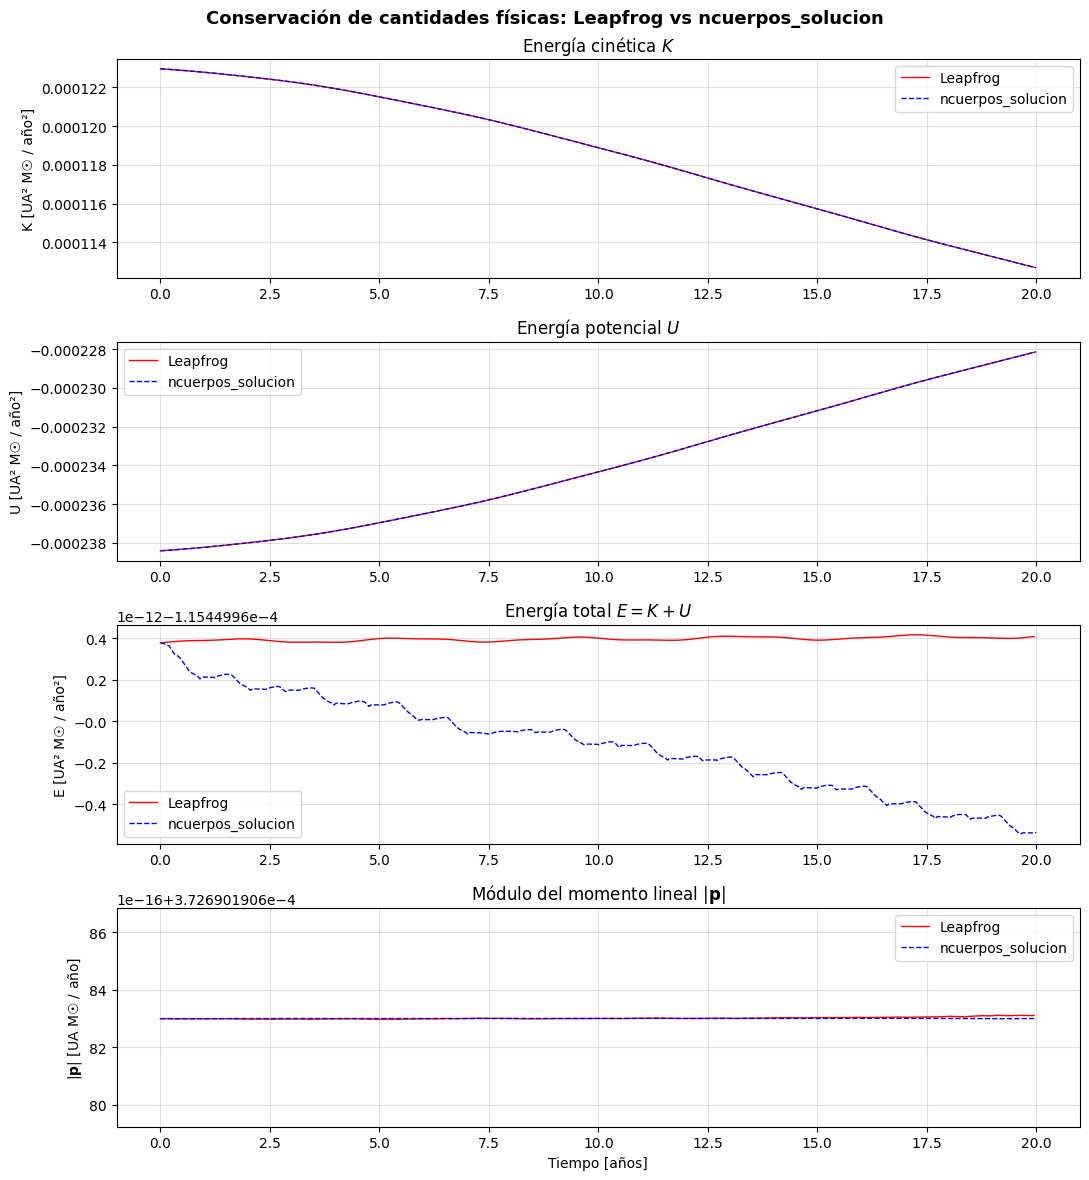

In [31]:
# GRÁFICA: K, U, E y p para ambos métodos

plt.figure(figsize=(11, 12))

#  Energía cinética K 
plt.subplot(4, 1, 1)
plt.plot(t_leap, K_leap, color='red', linewidth=1, label='Leapfrog')
plt.plot(ts, K_ncs, color='blue', linewidth=1, linestyle='--', label='ncuerpos_solucion')
plt.ylabel('K [UA² M☉ / año²]')
plt.title('Energía cinética $K$')
plt.legend()
plt.grid(True, alpha=0.4)

#  Energía potencial U 
plt.subplot(4, 1, 2)
plt.plot(t_leap, U_leap, color='red', linewidth=1, label='Leapfrog')
plt.plot(ts, U_ncs, color='blue', linewidth=1, linestyle='--', label='ncuerpos_solucion')
plt.ylabel('U [UA² M☉ / año²]')
plt.title('Energía potencial $U$')
plt.legend()
plt.grid(True, alpha=0.4)

#  Energía total E 
plt.subplot(4, 1, 3)
plt.plot(t_leap, E_leap, color='red', linewidth=1, label='Leapfrog')
plt.plot(ts, E_ncs, color='blue', linewidth=1, linestyle='--', label='ncuerpos_solucion')
plt.ylabel('E [UA² M☉ / año²]')
plt.title('Energía total $E = K + U$')
plt.legend()
plt.grid(True, alpha=0.4)

#  Momento lineal |p| 
plt.subplot(4, 1, 4)
plt.plot(t_leap, p_leap, color='red', linewidth=1, label='Leapfrog')
plt.plot(ts, p_ncs, color='blue', linewidth=1, linestyle='--', label='ncuerpos_solucion')
plt.ylabel(r'$|\mathbf{p}|$ [UA M☉ / año]')
plt.title('Módulo del momento lineal $|\mathbf{p}|$')
plt.xlabel('Tiempo [años]')
plt.legend()
plt.grid(True, alpha=0.4)

plt.suptitle('Conservación de cantidades físicas: Leapfrog vs ncuerpos_solucion',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Los valores de energía obtenidos son coherentes con los calculados previamente para el sistema con la  Luna ($E = -1.155 \times 10^{-4}$), confirmando que la Luna no altera significativamente la energía total del sistema debido a su baja masa.

El leapfrog conserva la energía con un error relativo máximo de $3.35 \times 10^{-10}$, superior a `ncuerpos_solucion` ($7.96 \times 10^{-9}$), lo cual es esperado dado que el leapfrog es un integrador simpléctico. Ambos métodos conservan el momento lineal con errores del orden de $10^{-14}$ y $10^{-15}$ respectivamente.

### Simulación con condiciones reales: REBOUND y NASA (Horizons)

Para poder estudiar el encuentro real de Apophis con la Tierra se utiliza **REBOUND**, que permite cargar posiciones y velocidades reales directamente desde las efemérides de **NASA Horizons**.

La simulación incluye todos los planetas del sistema solar y Apophis, con fecha de inicio el 1 de enero de 2027 y se integra hasta mediados de 2029 para capturar el encuentro de abril de 2029.

Se calcula la distancia Apophis-Tierra en cada paso de tiempo para determinar la fecha y distancia mínima del encuentro.

In [36]:
from datetime import datetime, timedelta

In [37]:
sim = rebound.Simulation()
sim.units = ('yr', 'AU', 'Msun')

In [38]:
fecha_inicio = "2027-01-01"

rebound.horizons.SSL_CONTEXT = 'unverified'

cuerpos = ["Sun", "Mercury", "Venus", "Earth", "Mars",
           "Jupiter", "Saturn", "Uranus", "Neptune", "99942"]

for cuerpo in cuerpos:
    sim.add(cuerpo, date=fecha_inicio)

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 


c:\Users\DEIBE\Desktop\Proyecto-del-curso-Apophis\.venv\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


In [39]:
sim.move_to_com()  
sim.integrator = "IAS15"

idx_tierra  = 3   # Earth
idx_apophis = 9   # 99942 Apophis

print("Cuerpos cargados desde Horizons:")
for i, p in enumerate(sim.particles):
    print(f"  [{i}] m = {p.m:.3e} Masas solares  |  r = ({p.x:.4f}, {p.y:.4f}, {p.z:.4f}) AU")

Cuerpos cargados desde Horizons:
  [0] m = 1.000e+00 Masas solares  |  r = (-0.0007, -0.0049, 0.0001) AU
  [1] m = 1.660e-07 Masas solares  |  r = (0.0679, -0.4562, -0.0431) AU
  [2] m = 2.448e-06 Masas solares  |  r = (-0.5621, 0.4420, 0.0386) AU
  [3] m = 3.040e-06 Masas solares  |  r = (-0.1706, 0.9637, 0.0000) AU
  [4] m = 3.227e-07 Masas solares  |  r = (-1.0251, 1.2833, 0.0522) AU
  [5] m = 9.548e-04 Masas solares  |  r = (-3.9921, 3.5355, 0.0747) AU
  [6] m = 2.859e-04 Masas solares  |  r = (9.1200, 2.2618, -0.4025) AU
  [7] m = 4.366e-05 Masas solares  |  r = (8.6039, 17.4098, -0.0468) AU
  [8] m = 5.151e-05 Masas solares  |  r = (29.8197, 1.6652, -0.7215) AU
  [9] m = 0.000e+00 Masas solares  |  r = (0.6823, 0.4434, -0.0077) AU


In [41]:
t_total  = 2.5        # años
n_puntos = 10000     
ts_sim   = np.linspace(0, t_total, n_puntos)

distancias = np.zeros(n_puntos)

for k, t in enumerate(ts_sim):
    sim.integrate(t)
    tierra  = sim.particles[idx_tierra]
    apophis = sim.particles[idx_apophis]
    
    dr = np.array([tierra.x - apophis.x,
                   tierra.y - apophis.y,
                   tierra.z - apophis.z])
    distancias[k] = np.linalg.norm(dr)

idx_min = np.argmin(distancias)
d_min   = distancias[idx_min]
t_min   = ts_sim[idx_min]

fecha_encuentro = datetime(2027, 1, 1) + timedelta(days=t_min * 365.25)

print(f"  RESULTADO DEL ENCUENTRO")
print(f"  Distancia mínima : {d_min:.6f} AU")
print(f"  Distancia mínima : {d_min * 149597870.7:.0f} km")
print(f"  Distancia mínima : {d_min * 149597870.7 / 384400:.2f} distancias lunares")
print(f"  Fecha aproximada : {fecha_encuentro.strftime('%Y-%m-%d %H:%M')}")

  RESULTADO DEL ENCUENTRO
  Distancia mínima : 0.000290 AU
  Distancia mínima : 43426 km
  Distancia mínima : 0.11 distancias lunares
  Fecha aproximada : 2029-04-13 22:46


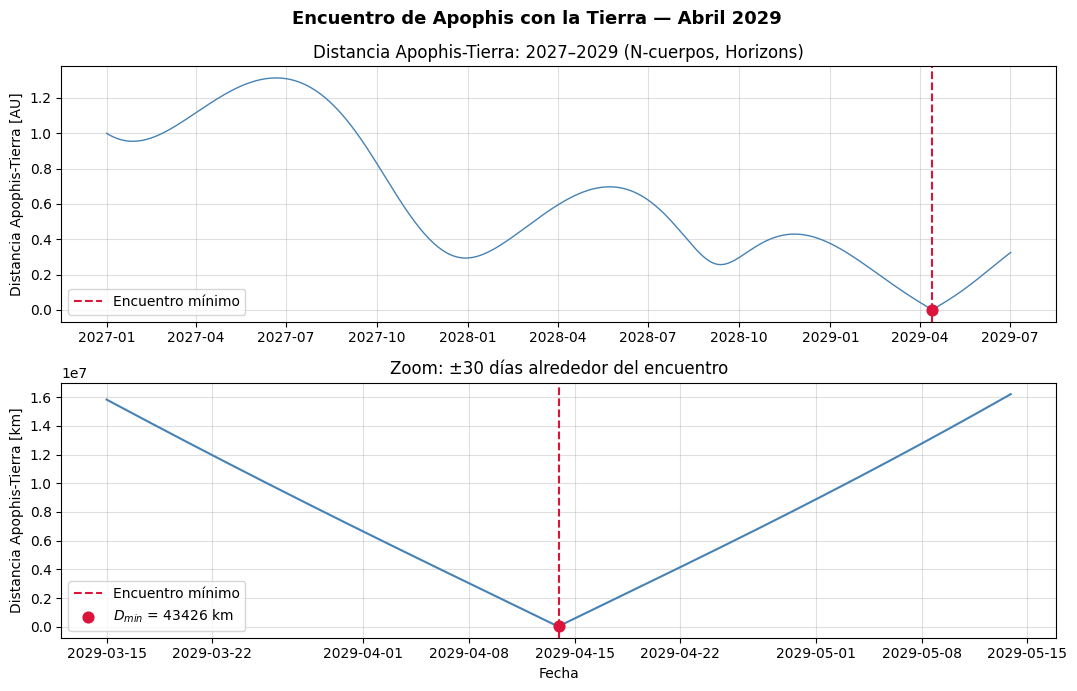

In [42]:
# Gráfica de distancia en el tiempo

fechas = [datetime(2027, 1, 1) + timedelta(days=t * 365.25) for t in ts_sim]

plt.figure(figsize=(11, 7))

plt.subplot(2, 1, 1)
plt.plot(fechas, distancias, color='steelblue', linewidth=1)
plt.axvline(fecha_encuentro, color='crimson', linestyle='--', label='Encuentro mínimo')
plt.scatter([fecha_encuentro], [d_min], color='crimson', zorder=5, s=60)
plt.ylabel('Distancia Apophis-Tierra [AU]')
plt.title('Distancia Apophis-Tierra: 2027–2029 (N-cuerpos, Horizons)')
plt.legend()
plt.grid(True, alpha=0.4)

mask = np.abs(ts_sim - t_min) < (30/365.25)
fechas_zoom = [fechas[i] for i in range(len(fechas)) if mask[i]]
dist_zoom   = distancias[mask]

plt.subplot(2, 1, 2)
plt.plot(fechas_zoom, dist_zoom * 149597870.7, color='steelblue', linewidth=1.5)
plt.axvline(fecha_encuentro, color='crimson', linestyle='--', label='Encuentro mínimo')
plt.scatter([fecha_encuentro], [d_min * 149597870.7],
            color='crimson', zorder=5, s=60,
            label=f'$D_{{min}}$ = {d_min*149597870.7:.0f} km')
plt.ylabel('Distancia Apophis-Tierra [km]')
plt.title('Zoom: ±30 días alrededor del encuentro')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.4)

plt.suptitle('Encuentro de Apophis con la Tierra — Abril 2029',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### Análisis 

La simulación realizada con REBOUND da una distancia mínima de $D_{min} = 43426$ km, lo cual es equivalente a $\approx 0.11$ distancias lunares. 

La fecha del máximo acercamiento se ubica en abril de 2029, y concuerda con las predicciones de NASA/JPL. La gráfica de distancia en el tiempo muestra además que Apophis tiene acercamientos periódicos a la Tierra debido a que sus órbitas se cruzan.

### Problema de dos cuerpos

Para analizar el encuentro desde la teoría, se tienen en cuenta a Apophis y la Tierra. Se extraen las posiciones y velocidades relativas de Apophis respecto a la Tierra desde Horizons el 13 de abril de 2029 y se calculan los elementos orbitales del problema de dos cuerpos:

- **Energía específica**: $\varepsilon = \frac{v^2}{2} - \frac{\mu}{r}$, donde $\mu = G \cdot M_{Tierra}$
- **Momento angular específico**: $\vec{h} = \vec{r} \times \vec{v}$
- **Semilatus rectum**: $p = \frac{h^2}{\mu}$
- **Excentricidad**: $e = \sqrt{1 + \frac{2\varepsilon h^2}{\mu^2}}$
- **Distancia de periapsis**: $r_{min} = \frac{p}{1+e}$

Con $\varepsilon > 0$ y $e > 1$ se confirma que la trayectoria relativa es una **hipérbola**: Apophis no queda orbitando la Tierra, sino que pasa y se aleja.

In [43]:
sim_2c = rebound.Simulation()
sim_2c.units = ('yr', 'AU', 'Msun')
rebound.horizons.SSL_CONTEXT = 'unverified'

for cuerpo in ["Sun", "399", "99942"]:
    sim_2c.add(cuerpo, date="2029-04-13")

sim_2c.move_to_com()

tierra  = sim_2c.particles[1]
apophis = sim_2c.particles[2]

r_vec = np.array([apophis.x  - tierra.x,
                  apophis.y  - tierra.y,
                  apophis.z  - tierra.z])

v_vec = np.array([apophis.vx - tierra.vx,
                  apophis.vy - tierra.vy,
                  apophis.vz - tierra.vz])

r = np.linalg.norm(r_vec)
v = np.linalg.norm(v_vec)

print(f"r = {r:.6f} AU")
print(f"v = {v:.6f} AU/año")

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 
r = 0.003233 AU
v = 1.262153 AU/año


In [57]:
# Energía específica
G_  = 4 * np.pi**2   # UA³ / (Masas solares · año²)
M_tierra = 3.0e-6    # masas solares

mu = G_ * M_tierra

E_orb = 0.5 * v**2 - mu / r

print(f"mu = {mu:.6e} AU³/año²")
print(f"E  = {E_orb:.6e} AU²/año²")
print(f"  {'hipérbola ' if E_orb > 0 else 'elipse'}")

mu = 1.184353e-04 AU³/año²
E  = 7.598790e-01 AU²/año²
  hipérbola 


In [46]:
# Momento angular específico
L_vec = np.cross(r_vec, v_vec)
L     = np.linalg.norm(L_vec)

print(f"L_vec = {L_vec}")
print(f"|L|   = {L:.6e} AU²/año")

L_vec = [ 5.51734867e-05  1.03199443e-04 -3.79831948e-04]
|L|   = 3.974501e-04 AU²/año


In [47]:
# Semilatus rectum y excentricidad
p = L**2 / mu
e = np.sqrt(1 + (2 * E_orb * L**2) / mu**2)

print(f"p = {p:.6e} AU")
print(f"e = {e:.6f}")

p = 1.333780e-03 AU
e = 4.256175


In [48]:
# Distancia mínima en la órbita de dos cuerpos
AU = 149597870.7  # km
LD = 384400       # km

r_min_2c = p / (1 + e)

print(f"r_min = {r_min_2c:.6f} AU")
print(f"      = {r_min_2c * AU:.0f} km")
print(f"      = {r_min_2c * AU / LD:.4f} LD")

r_min = 0.000254 AU
      = 37961 km
      = 0.0988 LD


In [60]:
# Comparación: Dos cuerpos vs N cuerpos
d_min_nc = 43426  

print(" Comparación dos cuerpos vs N cuerpos:")
print(f"  Dos cuerpos : {r_min_2c * AU:.0f} km  ({r_min_2c * AU / LD:.4f} LD)")
print(f"  N cuerpos   : {d_min_nc:.0f} km  ({d_min_nc / LD:.4f} LD)")
print(f"  diferencia  : {abs(r_min_2c * AU - d_min_nc):.0f} km")
print(f"  diferencia  : {abs(r_min_2c * AU - d_min_nc) / d_min_nc * 100:.2f} %")

 Comparación dos cuerpos vs N cuerpos:
  Dos cuerpos : 37961 km  (0.0988 LD)
  N cuerpos   : 43426 km  (0.1130 LD)
  diferencia  : 5465 km
  diferencia  : 12.58 %


#### Comparación: dos cuerpos vs N cuerpos

Se compara la distancia mínima obtenida con dos cuerpos ($r_{min}$) y la obtenida con la simulación de N cuerpos (REBOUND). La diferencia entre ambos resultados refleja el efecto de las perturbaciones gravitacionales de los demás planetas (principalmente Júpiter que es tan masivo) sobre la trayectoria de Apophis durante el acercamiento.

#### Trayectoria hiperbólica en el sistema astronómico

Para visualizar la hipérbola se utiliza el mismo enfoque visto en clase. Se calcula el **vector de excentricidad** $\vec{e}$ y con él el **argumento del periapsis** $\omega$:

$$\vec{e} = \frac{\vec{v} \times \vec{h}}{\mu} - \frac{\vec{r}}{r}$$

$$\cos\omega = \frac{\vec{e} \cdot \hat{x}}{e}$$

Con $\omega$ se construye la **matriz de rotación** $R_z(\omega)$ para pasar del sistema perifocal al sistema astronómico, y se grafica la hipérbola usando la ecuación de la cónica:

$$r(\theta) = \frac{p}{1 + e\cos\theta}$$


In [50]:
e_vec = np.cross(v_vec, L_vec) / mu - r_vec / r
print(f"e_vec = {e_vec}")
print(f"|e|   = {np.linalg.norm(e_vec):.6f}  (debe coincidir con e = {e:.6f})")

e_vec = [-2.13866589  3.61789001  0.67231464]
|e|   = 4.256175  (debe coincidir con e = 4.256175)


In [52]:
# Argumento del periapsis
w = np.arccos(e_vec @ np.array([1, 0, 0]) / e)

print(f"w= {w:.6f} rad  =  {np.degrees(w):.2f}°")

w= 2.097267 rad  =  120.16°


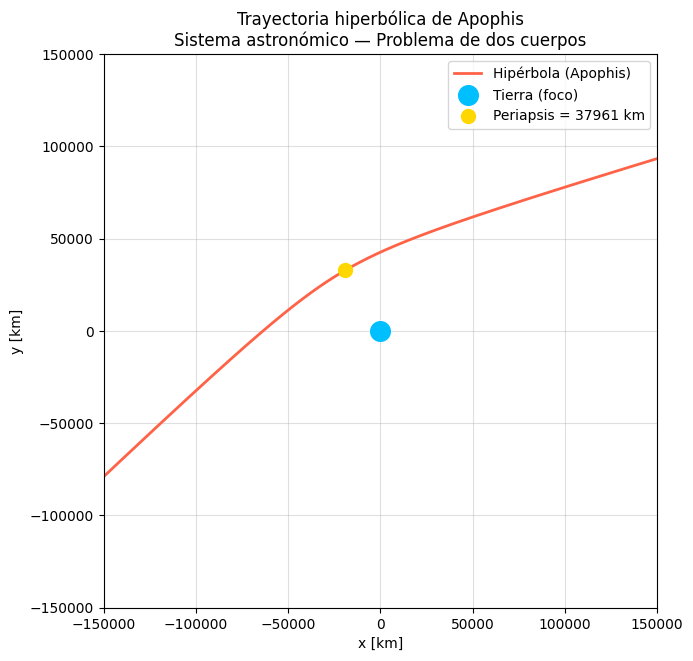

In [53]:
# Matriz de rotación 
Rz = np.array([
    [np.cos(w), -np.sin(w), 0],
    [np.sin(w),  np.cos(w), 0],
    [0,          0,         1]
])

# Hipérbola en el sistema perifocal
theta_max = np.arccos(-1/e)
theta = np.linspace(-theta_max * 0.95, theta_max * 0.95, 1000)

r_hip = p / (1 + e * np.cos(theta))
x_peri = r_hip * np.cos(theta) * AU
y_peri = r_hip * np.sin(theta) * AU
z_peri = np.zeros_like(x_peri)

# Rotar al sistema astronómico
rvecs = (Rz @ np.array([x_peri, y_peri, z_peri])).T

peri_perifocal = np.array([r_min_2c * AU, 0, 0])
peri_astro = Rz @ peri_perifocal


lim = 150000  

fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(rvecs[:,0], rvecs[:,1], color='tomato', lw=2, label='Hipérbola (Apophis)')
ax.scatter([0], [0], color='deepskyblue', s=200, zorder=5, label='Tierra (foco)')
ax.scatter([peri_astro[0]], [peri_astro[1]],
           color='gold', s=100, zorder=5,
           label=f'Periapsis = {r_min_2c * AU:.0f} km')

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal')
ax.set_xlabel('x [km]')
ax.set_ylabel('y [km]')
ax.set_title('Trayectoria hiperbólica de Apophis\nSistema astronómico — Problema de dos cuerpos')
ax.grid(True, alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()

### Cambio en los elementos orbitales heliocéntricos

El paso cercano de Apophis por la Tierra modifica su órbita alrededor del Sol. Para estudiar este efecto se extraen los elementos orbitales heliocéntricos de Apophis **antes** (1 enero 2029) y **después** (1 julio 2029) del acercamiento usando REBOUND.

Los parámetros son: el semieje mayor $a$, la excentricidad $e$, la inclinación $i$ y el periodo orbital $T$.

In [61]:
sim_orb = rebound.Simulation()
sim_orb.units = ('yr', 'AU', 'Msun')
rebound.horizons.SSL_CONTEXT = 'unverified'

for cuerpo in ["Sun", "Mercury", "Venus", "399", "Mars",
               "Jupiter", "Saturn", "Uranus", "Neptune", "99942"]:
    sim_orb.add(cuerpo, date="2029-01-01")

sim_orb.move_to_com()
sim_orb.integrator = "IAS15"

idx_apophis = 9

print("Sistema cargado correctamente")
print(f"Número de partículas: {sim_orb.N}")

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
Searching NASA Horizons for 'Jupiter'... 
Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Uranus'... 
Found: Uranus Barycenter (7) (chosen from query 'Uranus')
Searching NASA Horizons for 'Neptune'... 
Found: Neptune Barycenter (8) (chosen from query 'Neptune')
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 
Sistema cargado correctamente
Número de partículas: 10


In [63]:
# Elementos orbitales
orb_antes = sim_orb.particles[idx_apophis].orbit(primary=sim_orb.particles[0])

print(" Órbita de Apophis ANTES del acercamiento (2029-01-01) ")
print(f"  Semieje mayor    a = {orb_antes.a:.6f} AU")
print(f"  Excentricidad    e = {orb_antes.e:.6f}")
print(f"  Inclinación      i = {np.degrees(orb_antes.inc):.4f}°")
print(f"  Periodo          T = {orb_antes.P:.4f} años")

 Órbita de Apophis ANTES del acercamiento (2029-01-01) 
  Semieje mayor    a = 0.922386 AU
  Excentricidad    e = 0.191147
  Inclinación      i = 3.3415°
  Periodo          T = 0.8859 años


In [64]:
#  Integrar hasta después del acercamiento (1 julio 2029 = 0.5 años después)
sim_orb.integrate(0.5)

orb_despues = sim_orb.particles[idx_apophis].orbit(primary=sim_orb.particles[0])

print(" Órbita de Apophis DESPUÉS del acercamiento (2029-07-01)")
print(f"  Semieje mayor    a = {orb_despues.a:.6f} AU")
print(f"  Excentricidad    e = {orb_despues.e:.6f}")
print(f"  Inclinación      i = {np.degrees(orb_despues.inc):.4f}°")
print(f"  Periodo          T = {orb_despues.P:.4f} años")

 Órbita de Apophis DESPUÉS del acercamiento (2029-07-01)
  Semieje mayor    a = 0.960622 AU
  Excentricidad    e = 0.179371
  Inclinación      i = 3.0020°
  Periodo          T = 0.9415 años


In [67]:
# Comparación antes vs después
print(" Cambio en la órbita de Apophis  ")
print(f"{'Parámetro':<20} {'Antes':>12} {'Después':>12} {'Cambio':>12}")
print(f"{'a [AU]':<20} {orb_antes.a:>12.6f} {orb_despues.a:>12.6f} {orb_despues.a - orb_antes.a:>+12.6f}")
print(f"{'e':<20} {orb_antes.e:>12.6f} {orb_despues.e:>12.6f} {orb_despues.e - orb_antes.e:>+12.6f}")
print(f"{'i [°]':<20} {np.degrees(orb_antes.inc):>12.4f} {np.degrees(orb_despues.inc):>12.4f} {np.degrees(orb_despues.inc - orb_antes.inc):>+12.4f}")
print(f"{'T [años]':<20} {orb_antes.P:>12.4f} {orb_despues.P:>12.4f} {orb_despues.P - orb_antes.P:>+12.4f}")

 Cambio en la órbita de Apophis  
Parámetro                   Antes      Después       Cambio
a [AU]                   0.922386     0.960622    +0.038237
e                        0.191147     0.179371    -0.011776
i [°]                      3.3415       3.0020      -0.3395
T [años]                   0.8859       0.9415      +0.0557


### Conclusiones

- El integrador leapfrog  conserva la energía total con errores del orden de $10^{-10}$, confirmando su validez para simulaciones gravitacionales de largo plazo.

- La simulación con REBOUND y efemérides de NASA Horizons obtiene una distancia mínima de aproximación de $43426$ km en abril de 2029, que son acordes con las predicciones oficiales de NASA/JPL.

- El modelo de dos cuerpos predice una distancia mínima de $37961$ km, con una diferencia de $12.58\%$ respecto al resultado de N cuerpos que refleja el efecto de las perturbaciones planetarias.

- La trayectoria relativa de Apophis respecto a la Tierra durante el acercamiento es una hipérbola con excentricidad $e = 4.26$, confirmando que Apophis no queda capturado gravitacionalmente por la Tierra.

- El paso cercano modifica la órbita heliocéntrica de Apophis: el semieje mayor crece de $0.922$ a $0.961$ AU, la excentricidad disminuye de $0.191$ a $0.179$, y el periodo orbital aumenta. 